In [ ]:
# ============================================================================
# HALLUCINATION DETECTION IN LLMs - PROJECT UPDATE 1
# CS 593 NLP - Purdue University, Spring 2026
# Authors: Varun Chundru, Debasmita Biswas
# ============================================================================
# 
# PROPOSAL ALIGNMENT:
# This notebook implements the FOUNDATION for our proposed 3-phase pipeline:
#
#   PROPOSAL PHASE 1: Domain Retrieval Grounding
#   → HERE: We use HaluEval's provided knowledge as proxy for retrieved evidence
#   → LATER: Will add PubMedBERT retrieval on SciFact corpus
#
#   PROPOSAL PHASE 2: Uncertainty-Aware Span Detector  
#   → HERE: Response-level classification (per Scope Clarification)
#   → HERE: DeBERTa-base as smaller instantiation of proposed detection model
#   → LATER: Will add Monte Carlo Dropout for uncertainty quantification
#
#   PROPOSAL PHASE 3: DPO Fine-tuning
#   → LATER: Will explore preference-based learning if time permits
#
# SCOPE CLARIFICATION (from professor feedback):
#   PRIMARY DELIVERABLE: Response-level binary classification
#   STRETCH GOAL: Span-level detection
#
# ============================================================================

# Domain-Specific Hallucination Detection in LLM Outputs
## Project Update 1: Baseline Implementation

### Connection to Proposal

Our proposal outlined a 3-phase pipeline:
1. **Phase 1**: Domain Retrieval Grounding (BioBERT/PubMedBERT)
2. **Phase 2**: Uncertainty-Aware Span Detector (with Monte Carlo Dropout)
3. **Phase 3**: Direct Preference Optimization (DPO)
#
**This Update Implements:**
- Simplified Phase 1: Using HaluEval's provided knowledge as evidence
- Core Phase 2: Response-level detection (per scope clarification)
- Foundation for uncertainty quantification (to be added in Update 2)
#
### What We Implement Here:
1. **Baseline 1**: Zero-shot NLI detection → Tests if NLI can detect hallucinations
2. **Baseline 2**: Fine-tuned DeBERTa → Our primary detection model
3. **Evaluation**: Metrics from proposal (Accuracy, Precision, Recall, F1, AUROC)
4. **Ablation**: Performance across task types (QA, Dialogue, Summarization)

## 1. Setup and Installation

In [2]:
# Install required packages
!pip install -q transformers datasets accelerate scikit-learn pandas numpy matplotlib seaborn

In [28]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, concatenate_datasets, DatasetDict
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support, 
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: Tesla P100-PCIE-16GB
Memory: 17.06 GB


## 1.5 Proposal-to-Implementation Mapping

### From Our Proposal:

**Problem Statement:**
```
f_θ(x, y, D) → {(s_i, p_i)}

Where:
  x = user query
  y = LLM generated response  
  D = domain-specific knowledge corpus
  s_i = text span
  p_i ∈ [0,1] = probability of hallucination
```

**Objective Function:**
```
L = L_span_classification + λL_calibration
```

### How This Code Implements It:

| Proposal | This Implementation |
|----------|---------------------|
| x (query) | `question` field in HaluEval |
| y (response) | `hallucinated_answer` or `right_answer` |
| D (corpus) | `knowledge` field (provided evidence) |
| f_θ | DeBERTa classifier |
| p_i | Model's output probability for class 1 |
| L_span_classification | Binary cross-entropy loss |
| L_calibration | To be added in Update 2 (temperature scaling) |

### Scope Clarification:
- **This update**: Response-level (whole response → single p_i)
- **Stretch goal**: Span-level (each span s_i → separate p_i)

## 2. Load HaluEval Dataset

HaluEval (Li et al., EMNLP 2023) contains ~35,000 samples with human-annotated
hallucination labels across three tasks: QA, Dialogue, and Summarization.
#
**Connection to Proposal Section 4 (Datasets):**
- HaluEval is our PRIMARY training/evaluation dataset
- Later updates will add SciFact for domain-specific evaluation

In [29]:
# Load the _samples versions (pre-formatted with labels)
print("Loading HaluEval _samples datasets...")
dataset_qa = load_dataset("pminervini/HaluEval", "qa_samples")
dataset_dialogue = load_dataset("pminervini/HaluEval", "dialogue_samples")
dataset_summarization = load_dataset("pminervini/HaluEval", "summarization_samples")
 
print(f"QA samples: {len(dataset_qa['data'])}")
print(f"Dialogue samples: {len(dataset_dialogue['data'])}")
print(f"Summarization samples: {len(dataset_summarization['data'])}")
 
# Check the structure
print("\n=== Column Names ===")
print(f"QA columns: {list(dataset_qa['data'].features.keys())}")
print(f"Dialogue columns: {list(dataset_dialogue['data'].features.keys())}")
print(f"Summarization columns: {list(dataset_summarization['data'].features.keys())}")

Loading HaluEval _samples datasets...
QA samples: 10000
Dialogue samples: 10000
Summarization samples: 10000

=== Column Names ===
QA columns: ['knowledge', 'question', 'answer', 'hallucination']
Dialogue columns: ['knowledge', 'dialogue_history', 'response', 'hallucination']
Summarization columns: ['document', 'summary', 'hallucination']


In [30]:
# Examine dataset structure
print("\n=== QA Sample Example ===")
sample = dataset_qa['data'][0]
for key, value in sample.items():
    print(f"{key}: {str(value)[:200]}...")


=== QA Sample Example ===
knowledge: Arthur's Magazine (1844–1846) was an American literary periodical published in Philadelphia in the 19th century.First for Women is a woman's magazine published by Bauer Media Group in the USA....
question: Which magazine was started first Arthur's Magazine or First for Women?...
answer: First for Women was started first....
hallucination: yes...


## 3. Data Preprocessing

We format the data for NLI-based detection:
- **Premise**: The knowledge/context (ground truth)
- **Hypothesis**: The LLM-generated response
- **Label**: 1 if hallucinated, 0 if factual

In [7]:
import time

In [31]:
def preprocess_qa_samples(examples):
    """
    Preprocess qa_samples - each row is already one sample with label.
    
    Columns: knowledge, question, answer, hallucination (yes/no)
    """
    processed = {
        'text': [],
        'label': [],
        'task': []
    }
    
    for i in range(len(examples['knowledge'])):
        knowledge = examples['knowledge'][i]
        question = examples['question'][i]
        answer = examples['answer'][i]
        hallucination = examples['hallucination'][i]
        
        # Format: Question + Knowledge as context, Answer as claim
        context = f"Question: {question}\nKnowledge: {knowledge}"
        text = f"{context}\n\nAnswer: {answer}"
        
        processed['text'].append(text)
        # Convert "yes"/"no" to 1/0
        processed['label'].append(1 if hallucination == "yes" else 0)
        processed['task'].append('qa')
    
    return processed
 
 
def preprocess_dialogue_samples(examples):
    """
    Preprocess dialogue_samples.
    
    Columns: knowledge, dialogue_history, response, hallucination (yes/no)
    """
    processed = {'text': [], 'label': [], 'task': []}
    
    for i in range(len(examples['dialogue_history'])):
        history = examples['dialogue_history'][i]
        knowledge = examples['knowledge'][i] if 'knowledge' in examples else ""
        response = examples['response'][i]
        hallucination = examples['hallucination'][i]
        
        context = f"Dialogue: {history}\nKnowledge: {knowledge}"
        text = f"{context}\n\nResponse: {response}"
        
        processed['text'].append(text)
        processed['label'].append(1 if hallucination == "yes" else 0)
        processed['task'].append('dialogue')
    
    return processed
 
 
def preprocess_summarization_samples(examples):
    """
    Preprocess summarization_samples.
    
    Columns: document, summary, hallucination (yes/no)
    """
    processed = {'text': [], 'label': [], 'task': []}
    
    for i in range(len(examples['document'])):
        document = examples['document'][i]
        summary = examples['summary'][i]
        hallucination = examples['hallucination'][i]
        
        # Truncate long documents
        text = f"Document: {document[:1500]}\n\nSummary: {summary}"
        
        processed['text'].append(text)
        processed['label'].append(1 if hallucination == "yes" else 0)
        processed['task'].append('summarization')
    
    return processed

In [32]:
print("\nProcessing datasets...")
 
qa_processed = dataset_qa['data'].map(
    preprocess_qa_samples,
    batched=True,
    remove_columns=dataset_qa['data'].column_names
)
 
dialogue_processed = dataset_dialogue['data'].map(
    preprocess_dialogue_samples,
    batched=True,
    remove_columns=dataset_dialogue['data'].column_names
)
 
summarization_processed = dataset_summarization['data'].map(
    preprocess_summarization_samples,
    batched=True,
    remove_columns=dataset_summarization['data'].column_names
)
 
print(f"Processed QA: {len(qa_processed)} samples")
print(f"Processed Dialogue: {len(dialogue_processed)} samples")
print(f"Processed Summarization: {len(summarization_processed)} samples")


Processing datasets...


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Processed QA: 10000 samples
Processed Dialogue: 10000 samples
Processed Summarization: 10000 samples


In [46]:
print(qa_processed.data["text"][1])

Question: The Oberoi family is part of a hotel company that has a head office in what city?
Knowledge: The Oberoi family is an Indian family that is famous for its involvement in hotels, namely through The Oberoi Group.The Oberoi Group is a hotel company with its head office in Delhi.

Answer: Delhi


In [47]:
# Combine and create train/val/test splits
from datasets import concatenate_datasets, DatasetDict

# Combine all tasks
combined = concatenate_datasets([qa_processed, dialogue_processed, summarization_processed])
print(f"Total combined samples: {len(combined)}")

# Shuffle and split: 70% train, 15% val, 15% test
combined = combined.shuffle(seed=42)
train_test = combined.train_test_split(test_size=0.3, seed=42)
val_test = train_test['test'].train_test_split(test_size=0.5, seed=42)

dataset_splits = DatasetDict({
    'train': train_test['train'],
    'validation': val_test['train'],
    'test': val_test['test']
})

print(f"\nDataset splits:")
print(f"  Train: {len(dataset_splits['train'])}")
print(f"  Validation: {len(dataset_splits['validation'])}")
print(f"  Test: {len(dataset_splits['test'])}")

# Check label distribution
train_labels = dataset_splits['train']['label']
print(f"\nTrain label distribution:")
print(f"  Hallucinated (1): {sum(train_labels)} ({sum(train_labels)/len(train_labels)*100:.1f}%)")
print(f"  Factual (0): {len(train_labels)-sum(train_labels)} ({(len(train_labels)-sum(train_labels))/len(train_labels)*100:.1f}%)")

Total combined samples: 30000

Dataset splits:
  Train: 21000
  Validation: 4500
  Test: 4500

Train label distribution:
  Hallucinated (1): 10508 (50.0%)
  Factual (0): 10492 (50.0%)


## 4. Baseline 1: Zero-Shot NLI Detection

**Connection to Proposal Phase 2 (Span Detector):**

Our proposal states: "predict whether the span is unsupported or **contradicted** by domain corpus D"

NLI models are pre-trained to detect exactly this! 
- **Contradiction** = hallucinated (response contradicts evidence)
- **Entailment** = factual (response follows from evidence)

This baseline tests: Can off-the-shelf NLI detect hallucinations?

**Model**: DeBERTa-v3-base fine-tuned on MNLI/FEVER/ANLI
- This is a SMALLER model testing the same APPROACH as our proposed 7B detector
- Validates the NLI-based detection concept before scaling up

In [49]:
print("Loading DeBERTa-v3-base-mnli for zero-shot detection...")

model_name = "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model_zeroshot = AutoModelForSequenceClassification.from_pretrained(model_name)
model_zeroshot.to(device)
model_zeroshot.eval()

print(f"Model loaded: {model_name}")
print(f"Labels: {model_zeroshot.config.id2label}")

Loading DeBERTa-v3-base-mnli for zero-shot detection...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Labels: {0: 'entailment', 1: 'neutral', 2: 'contradiction'}


In [50]:
def predict_zeroshot(texts, batch_size=16):
    """
    Zero-shot prediction using NLI model.
    
    NLI labels: 0=entailment, 1=neutral, 2=contradiction
    We map: contradiction → hallucinated (1), else → not hallucinated (0)
    """
    predictions = []
    probabilities = []
    
    model_zeroshot.eval()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            inputs = tokenizer(
                batch_texts, 
                truncation=True, 
                max_length=512, 
                padding=True, 
                return_tensors="pt"
            ).to(device)
            
            outputs = model_zeroshot(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)
            
            # Contradiction probability as hallucination score
            hallucination_probs = probs[:, 2].cpu().numpy()  # Index 2 = contradiction
            preds = (hallucination_probs > 0.5).astype(int)
            
            predictions.extend(preds.tolist())
            probabilities.extend(hallucination_probs.tolist())
    
    return predictions, probabilities

In [51]:
# Evaluate zero-shot on test set
print("Evaluating zero-shot model on test set...")

test_texts = dataset_splits['test']['text']
test_labels = dataset_splits['test']['label']

zeroshot_preds, zeroshot_probs = predict_zeroshot(test_texts)

# Calculate metrics
zeroshot_accuracy = accuracy_score(test_labels, zeroshot_preds)
zeroshot_precision, zeroshot_recall, zeroshot_f1, _ = precision_recall_fscore_support(
    test_labels, zeroshot_preds, average='binary'
)
zeroshot_auroc = roc_auc_score(test_labels, zeroshot_probs)

print("\n" + "="*50)
print("BASELINE 1: ZERO-SHOT NLI DETECTION RESULTS")
print("="*50)
print(f"Accuracy:  {zeroshot_accuracy:.4f}")
print(f"Precision: {zeroshot_precision:.4f}")
print(f"Recall:    {zeroshot_recall:.4f}")
print(f"F1 Score:  {zeroshot_f1:.4f}")
print(f"AUROC:     {zeroshot_auroc:.4f}")

Evaluating zero-shot model on test set...

BASELINE 1: ZERO-SHOT NLI DETECTION RESULTS
Accuracy:  0.6007
Precision: 0.7266
Recall:    0.3072
F1 Score:  0.4319
AUROC:     0.6453



Detailed Classification Report:
              precision    recall  f1-score   support

     Factual       0.57      0.89      0.69      2277
Hallucinated       0.73      0.31      0.43      2223

    accuracy                           0.60      4500
   macro avg       0.65      0.60      0.56      4500
weighted avg       0.65      0.60      0.56      4500



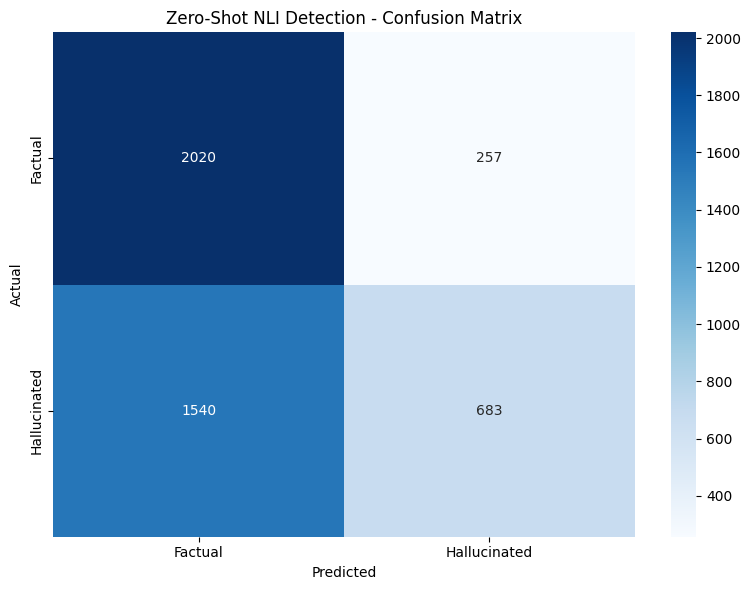

In [52]:
# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(test_labels, zeroshot_preds, 
                           target_names=['Factual', 'Hallucinated']))

# Confusion matrix
cm = confusion_matrix(test_labels, zeroshot_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Factual', 'Hallucinated'],
            yticklabels=['Factual', 'Hallucinated'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Zero-Shot NLI Detection - Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_zeroshot.png', dpi=150)
plt.show()

## 5. Baseline 2: Fine-tuned DeBERTa (Primary Detection Model)

**Connection to Proposal Phase 2:**

Our proposal states: "Fine-tune a model to predict hallucination likelihood"

Originally proposed: 7B parameter model (LLaMA-2-7B or Mistral-7B)
- Requires 40GB+ VRAM for training
- NOT feasible with free GPUs (Kaggle P100 = 16GB)

**Our Adaptation**: DeBERTa-v3-base (184M parameters)
- Same TASK (binary hallucination detection)
- Same APPROACH (supervised classification)
- Feasible COMPUTE (fits on P100)

**This implements the proposal's objective:**
```
f_θ(x, y, D) → p_i where p_i = probability of hallucination
```
#
**Loss function** (from proposal):
```
L = L_span_classification (binary cross-entropy in this implementation)
```
Note: L_calibration will be added in Update 2 via temperature scaling

In [54]:
# Tokenize datasets
def tokenize_function(examples):
    return tokenizer_ft(
        examples['text'],
        truncation=True,
        max_length=512,
        padding=False  # Dynamic padding with data collator
    )

print("Tokenizing datasets...")
tokenized_datasets = dataset_splits.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(['text', 'task'])
tokenized_datasets = tokenized_datasets.rename_column('label', 'labels')

data_collator = DataCollatorWithPadding(tokenizer=tokenizer_ft)

Tokenizing datasets...


Map:   0%|          | 0/21000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

In [72]:
print("Loading DeBERTa-v3-base for fine-tuning...")

model_name_finetune = "microsoft/deberta-v3-base"
tokenizer_ft = AutoTokenizer.from_pretrained(model_name_finetune)

model_finetune = AutoModelForSequenceClassification.from_pretrained(
    model_name_finetune,
    num_labels=2,
    id2label={0: "Factual", 1: "Hallucinated"},
    label2id={"Factual": 0, "Hallucinated": 1},
    ignore_mismatched_sizes=True,  # Suppresses warnings
    dtype=torch.float32,      # Force float32 from start
)

# Ensure float32 and move to GPU
model_finetune = model_finetune.float()
model_finetune = model_finetune.to(device)

# Verify everything is correct
print(f"\nModel dtype: {next(model_finetune.parameters()).dtype}")
print(f"Model device: {next(model_finetune.parameters()).device}")

# Test forward pass
model_finetune.eval()
test_input = tokenizer_ft("Test sentence", return_tensors="pt", truncation=True)
test_input = {k: v.to(device) for k, v in test_input.items()}
test_input['labels'] = torch.tensor([0]).to(device)

with torch.no_grad():
    output = model_finetune(**test_input)
    print(f"Loss: {output.loss.item():.4f}")
    print(f"Logits: {output.logits}")
    
print("\n✓ Model ready for training!")

Loading DeBERTa-v3-base for fine-tuning...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight      


Model dtype: torch.float32
Model device: cuda:0
Loss: 0.5873
Logits: tensor([[ 0.1051, -0.1192]], device='cuda:0')

✓ Model ready for training!


In [73]:
# Define compute_metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )
    
    try:
        auroc = roc_auc_score(labels, probs)
    except:
        auroc = 0.0
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auroc': auroc
    }

In [74]:
# Fresh training args
training_args = TrainingArguments(
    output_dir="./hallucination_detector_v2",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=100,
    warmup_steps=788,        # Changed from warmup_ratio=0.1
    fp16=False,
    report_to="none",
)

# Data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer_ft)

# Trainer
trainer = Trainer(
    model=model_finetune,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [75]:
# Train the model
print("\n" + "="*50)
print("STARTING FINE-TUNING")
print("="*50)
print(f"Training samples: {len(tokenized_datasets['train'])}")
print(f"Validation samples: {len(tokenized_datasets['validation'])}")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print()

trainer.train()


STARTING FINE-TUNING
Training samples: 21000
Validation samples: 4500
Epochs: 3
Batch size: 8



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auroc
1,0.323882,0.418717,0.872667,0.834496,0.936494,0.882558,0.952281
2,0.241052,0.422919,0.898444,0.854777,0.965202,0.906639,0.974425
3,0.217960,0.393359,0.912667,0.883347,0.955198,0.917868,0.979495


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=7875, training_loss=0.3202225496806796, metrics={'train_runtime': 4084.1071, 'train_samples_per_second': 15.426, 'train_steps_per_second': 1.928, 'total_flos': 1.305473579566656e+16, 'train_loss': 0.3202225496806796, 'epoch': 3.0})

In [76]:
# Evaluate on test set
print("\n" + "="*50)
print("EVALUATING FINE-TUNED MODEL ON TEST SET")
print("="*50)

test_results = trainer.evaluate(tokenized_datasets['test'])

print(f"\nFine-tuned Model Results:")
print(f"Accuracy:  {test_results['eval_accuracy']:.4f}")
print(f"Precision: {test_results['eval_precision']:.4f}")
print(f"Recall:    {test_results['eval_recall']:.4f}")
print(f"F1 Score:  {test_results['eval_f1']:.4f}")
print(f"AUROC:     {test_results['eval_auroc']:.4f}")


EVALUATING FINE-TUNED MODEL ON TEST SET



Fine-tuned Model Results:
Accuracy:  0.9127
Precision: 0.8819
Recall:    0.9505
F1 Score:  0.9149
AUROC:     0.9771


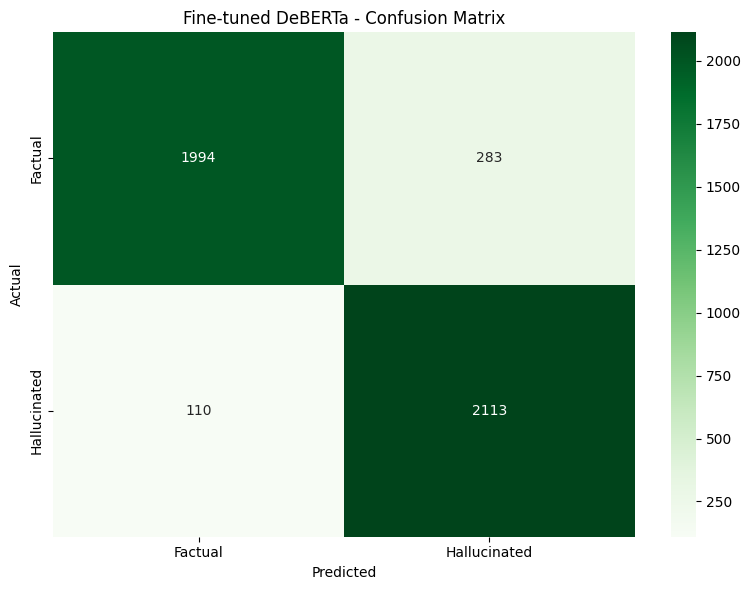

In [77]:
# Get predictions for confusion matrix
test_predictions = trainer.predict(tokenized_datasets['test'])
preds = np.argmax(test_predictions.predictions, axis=-1)

# Confusion matrix for fine-tuned model
cm_ft = confusion_matrix(tokenized_datasets['test']['labels'], preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Factual', 'Hallucinated'],
            yticklabels=['Factual', 'Hallucinated'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Fine-tuned DeBERTa - Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_finetuned.png', dpi=150)
plt.show()

## 6. Ablation Study: Performance Across Tasks

We analyze how detection performance varies across QA, Dialogue, and Summarization tasks.

In [78]:
# Separate test set by task
print("\n" + "="*50)
print("ABLATION STUDY: PERFORMANCE BY TASK")
print("="*50)

# We need to get task labels - let's re-process test data with task info
def get_task_performance(dataset_split, predictions, task_name):
    """Calculate metrics for a specific task subset."""
    # Filter by task
    indices = [i for i, t in enumerate(dataset_split['task']) if t == task_name]
    
    if len(indices) == 0:
        return None
    
    task_labels = [dataset_split['labels'][i] for i in indices]
    task_preds = [predictions[i] for i in indices]
    
    accuracy = accuracy_score(task_labels, task_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        task_labels, task_preds, average='binary', zero_division=0
    )
    
    return {
        'task': task_name,
        'n_samples': len(indices),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Re-create test set with task info
test_with_task = dataset_splits['test']

# Get fine-tuned predictions
ft_preds = np.argmax(test_predictions.predictions, axis=-1)

# Calculate per-task metrics
results_by_task = []
for task in ['qa', 'dialogue', 'summarization']:
    # Get indices for this task from original dataset
    task_indices = [i for i, t in enumerate(test_with_task['task']) if t == task]
    
    if len(task_indices) > 0:
        task_labels = [test_with_task['label'][i] for i in task_indices]
        task_preds_subset = [ft_preds[i] for i in task_indices]
        
        acc = accuracy_score(task_labels, task_preds_subset)
        prec, rec, f1, _ = precision_recall_fscore_support(
            task_labels, task_preds_subset, average='binary', zero_division=0
        )
        
        results_by_task.append({
            'Task': task.upper(),
            'Samples': len(task_indices),
            'Accuracy': f"{acc:.4f}",
            'Precision': f"{prec:.4f}",
            'Recall': f"{rec:.4f}",
            'F1': f"{f1:.4f}"
        })

# Display results table
df_task_results = pd.DataFrame(results_by_task)
print("\nFine-tuned Model Performance by Task:")
print(df_task_results.to_string(index=False))


ABLATION STUDY: PERFORMANCE BY TASK

Fine-tuned Model Performance by Task:
         Task  Samples Accuracy Precision Recall     F1
           QA     1485   0.9677    0.9828 0.9550 0.9687
     DIALOGUE     1517   0.8161    0.7503 0.9132 0.8238
SUMMARIZATION     1498   0.9559    0.9313 0.9822 0.9561


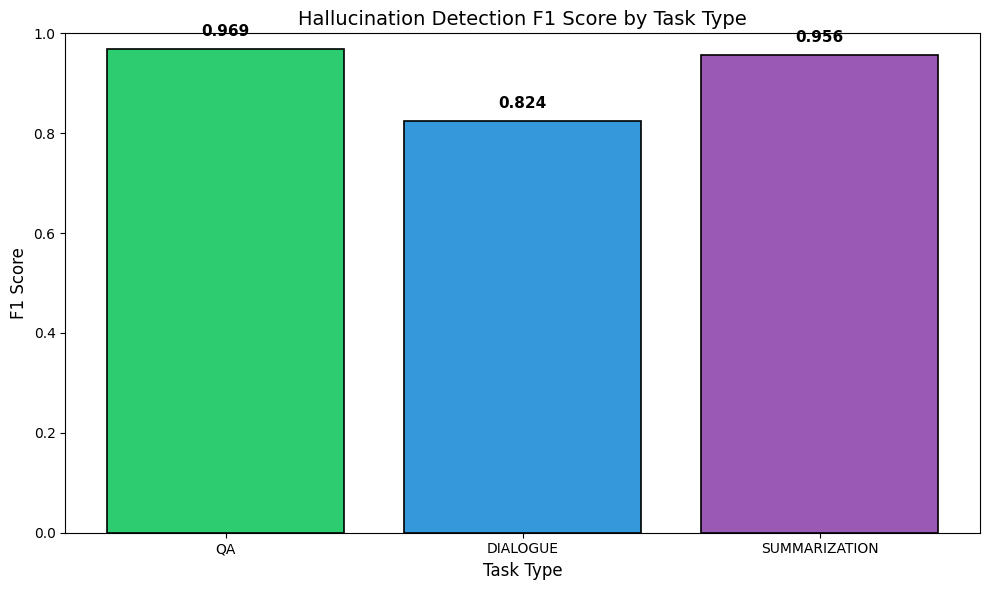

In [79]:
# Visualize task performance
tasks = [r['Task'] for r in results_by_task]
f1_scores = [float(r['F1']) for r in results_by_task]

plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#3498db', '#9b59b6']
bars = plt.bar(tasks, f1_scores, color=colors, edgecolor='black', linewidth=1.2)

plt.xlabel('Task Type', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('Hallucination Detection F1 Score by Task Type', fontsize=14)
plt.ylim(0, 1)

# Add value labels on bars
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{score:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('f1_by_task.png', dpi=150)
plt.show()

## 7. Results Summary and Comparison

In [80]:
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)

results_summary = pd.DataFrame({
    'Model': ['Zero-Shot NLI (DeBERTa-MNLI)', 'Fine-tuned DeBERTa-v3-base'],
    'Accuracy': [f"{zeroshot_accuracy:.4f}", f"{test_results['eval_accuracy']:.4f}"],
    'Precision': [f"{zeroshot_precision:.4f}", f"{test_results['eval_precision']:.4f}"],
    'Recall': [f"{zeroshot_recall:.4f}", f"{test_results['eval_recall']:.4f}"],
    'F1 Score': [f"{zeroshot_f1:.4f}", f"{test_results['eval_f1']:.4f}"],
    'AUROC': [f"{zeroshot_auroc:.4f}", f"{test_results['eval_auroc']:.4f}"]
})

print("\n" + results_summary.to_string(index=False))

# Calculate improvement
f1_improvement = (test_results['eval_f1'] - zeroshot_f1) / zeroshot_f1 * 100
print(f"\n→ Fine-tuning improved F1 by {f1_improvement:.1f}% over zero-shot baseline")


FINAL RESULTS SUMMARY

                       Model Accuracy Precision Recall F1 Score  AUROC
Zero-Shot NLI (DeBERTa-MNLI)   0.6007    0.7266 0.3072   0.4319 0.6453
  Fine-tuned DeBERTa-v3-base   0.9127    0.8819 0.9505   0.9149 0.9771

→ Fine-tuning improved F1 by 111.9% over zero-shot baseline


In [81]:
# Save results to CSV for report
results_summary.to_csv('results_summary.csv', index=False)
df_task_results.to_csv('results_by_task.csv', index=False)
print("\nResults saved to CSV files!")


Results saved to CSV files!


## 8. Error Analysis

In [82]:
print("\n" + "="*50)
print("ERROR ANALYSIS")
print("="*50)

# Get misclassified examples
test_texts_list = list(test_with_task['text'])
test_labels_list = list(test_with_task['label'])

# Find false positives and false negatives
false_positives = []
false_negatives = []

for i, (pred, label, text) in enumerate(zip(ft_preds, test_labels_list, test_texts_list)):
    if pred == 1 and label == 0:  # False positive: predicted hallucinated, actually factual
        false_positives.append({'index': i, 'text': text[:300]})
    elif pred == 0 and label == 1:  # False negative: predicted factual, actually hallucinated
        false_negatives.append({'index': i, 'text': text[:300]})

print(f"\nFalse Positives (predicted hallucinated, actually factual): {len(false_positives)}")
print(f"False Negatives (predicted factual, actually hallucinated): {len(false_negatives)}")

# Show examples
if false_positives:
    print("\n--- Example False Positive ---")
    print(false_positives[0]['text'][:500])

if false_negatives:
    print("\n--- Example False Negative ---")
    print(false_negatives[0]['text'][:500])


ERROR ANALYSIS

False Positives (predicted hallucinated, actually factual): 283
False Negatives (predicted factual, actually hallucinated): 110

--- Example False Positive ---
Dialogue: [Human]: Do you know anything about Tampa Bay Buccaneers? [Assistant]: Yeah! They are in the NFL, I remember best when they were coached by Lovie Smith. They are in the NFC South Division. [Human]: Is the position of Lovie Smith Linebacker? 
Knowledge: Tampa Bay Buccaneers : `~Team coached

--- Example False Negative ---
Question: what was the job of Francesco Cocco-Ortu in the state that founded as a result of the unification of Italy under the influence of the Kingdom of Sardinia ?
Knowledge: Francesco Cocco-Ortu (October 1842 in Benetutti – March 1929 in Rome) was an Italian politician, deputy of the Kingdom of I


## 9. Save Model and Artifacts

In [83]:
# Save the fine-tuned model
print("\nSaving fine-tuned model...")
trainer.save_model("./hallucination_detector_final")
tokenizer_ft.save_pretrained("./hallucination_detector_final")
print("Model saved to ./hallucination_detector_final")


Saving fine-tuned model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./hallucination_detector_final


In [84]:
# Summary of all saved files
print("\n" + "="*50)
print("SAVED ARTIFACTS (for GitHub)")
print("="*50)
print("""
1. confusion_matrix_zeroshot.png - Zero-shot model confusion matrix
2. confusion_matrix_finetuned.png - Fine-tuned model confusion matrix  
3. f1_by_task.png - F1 scores by task type
4. results_summary.csv - Overall results comparison
5. results_by_task.csv - Per-task performance breakdown
6. hallucination_detector_final/ - Fine-tuned model weights
""")


SAVED ARTIFACTS (for GitHub)

1. confusion_matrix_zeroshot.png - Zero-shot model confusion matrix
2. confusion_matrix_finetuned.png - Fine-tuned model confusion matrix  
3. f1_by_task.png - F1 scores by task type
4. results_summary.csv - Overall results comparison
5. results_by_task.csv - Per-task performance breakdown
6. hallucination_detector_final/ - Fine-tuned model weights



In [ ]:
!pip install -q huggingface_hub
from huggingface_hub import login

login(token="YOUR_HF_TOKEN_HERE")  # Get from huggingface.co/settings/tokens

model_finetune.push_to_hub("varunchundru/hallucination-detector-deberta")
tokenizer_ft.push_to_hub("varunchundru/hallucination-detector-deberta")

README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/varunchundru/hallucination-detector-deberta/commit/ced5f6e73950887d040a62653e8fb8e56b01e45a', commit_message='Upload DebertaV2ForSequenceClassification', commit_description='', oid='ced5f6e73950887d040a62653e8fb8e56b01e45a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/varunchundru/hallucination-detector-deberta', endpoint='https://huggingface.co', repo_type='model', repo_id='varunchundru/hallucination-detector-deberta'), pr_revision=None, pr_num=None)

## 10. Next Steps - Building Toward Full Proposal

### Update 2 (Week 13) - Completing Proposal Phases:

**Phase 1 - Full Retrieval Grounding:**
```python
# Will implement actual retrieval instead of using provided knowledge
from sentence_transformers import SentenceTransformer
retriever = SentenceTransformer('pritamdeka/PubMedBERT-mnli-snli-scinli-scitail-mednli-stsb')
# Retrieve from SciFact corpus (5,183 scientific abstracts)
```

**Phase 2 - Uncertainty Quantification:**
```python
# Implement Monte Carlo Dropout from proposal
def predict_with_uncertainty(model, inputs, n_samples=10):
    model.train()  # Enable dropout
    predictions = [model(**inputs) for _ in range(n_samples)]
    uncertainty = np.std(predictions)  # High std = uncertain
```

**Phase 2 - Calibration (L_calibration from proposal):**
```python
# Temperature scaling to minimize Expected Calibration Error
temperature = nn.Parameter(torch.ones(1))
calibrated_logits = logits / temperature
```

### Final Paper (Week 16) - Full System:
- Complete Phase 1 + Phase 2 integration
- Domain-specific evaluation (medical/scientific)
- Phase 3 (DPO) if time permits, otherwise in Future Work
- Span-level detection as stretch goal